In [30]:
import glob, os, sys, json, pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import AutoEncoder_Experiment
from flax.serialization import from_state_dict, to_state_dict
%matplotlib inline

In [34]:
class Experiment_Analyzer():
    """
    Can be instanced with a json file used to run the experiment
    >>>analyzer = Experiment_Analyzer(json_fn)
    
    """
    def __init__(self, json_fn=None, chkpt_fn=None):
        assert json_fn is not None
        self.experiment = AutoEncoder_Experiment.AutoEncoder_Experiment(json_fn)
        assert chkpt_fn is not None
        with open(chkpt_fn, 'rb') as g:
            self.experiment.state = from_state_dict(self.experiment.state, pickle.load(g))
        


In [39]:
#I'd load one at a time

rmsd = Experiment_Analyzer('./Sigmoids_Softmaxs.json', './SigSoftTest/07_latents/rpt_1/model_ckpt_002000.pkl')
final = Experiment_Analyzer('./Sigmoids_Softmaxs.json', './SigSoftTest/07_latents/rpt_1/model_ckpt_006000.pkl')
early = Experiment_Analyzer('./Sigmoids_Softmaxs.json', './SigSoftTest/07_latents/rpt_1/model_ckpt_003000.pkl')

(8000, 306) (2000, 306)
### MODEL TYPE = AE_Sigmoid ###
Softmax_Sigmoid_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 7
)
INITIALIZATION COMPLETE
(8000, 306) (2000, 306)
### MODEL TYPE = AE_Sigmoid ###
Softmax_Sigmoid_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 7
)
INITIALIZATION COMPLETE
(8000, 306) (2000, 306)
### MODEL TYPE = AE_Sigmoid ###
Softmax_Sigmoid_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    n_latents = 7
)
INITIALIZATION COMPLETE


In [40]:
rmsd_decoded, rmsd_latents = rmsd.experiment.state.apply_fn({'params':rmsd.experiment.state.params}, rmsd.experiment.test_data)
final_decoded, final_latents = final.experiment.state.apply_fn({'params':final.experiment.state.params}, final.experiment.test_data)
early_decoded, early_latents = early.experiment.state.apply_fn({'params':early.experiment.state.params}, early.experiment.test_data)

In [41]:
np.where(final_latents != early_latents)

(array([   0,    0,    0, ..., 1999, 1999, 1999]),
 array([0, 1, 2, ..., 4, 5, 6]))

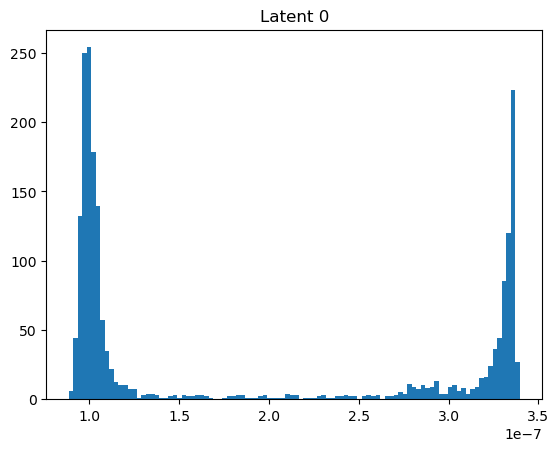

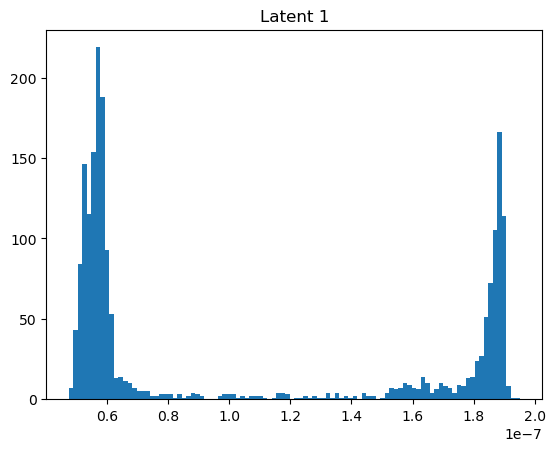

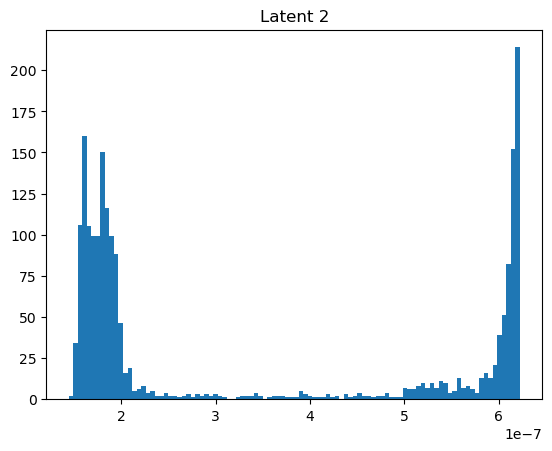

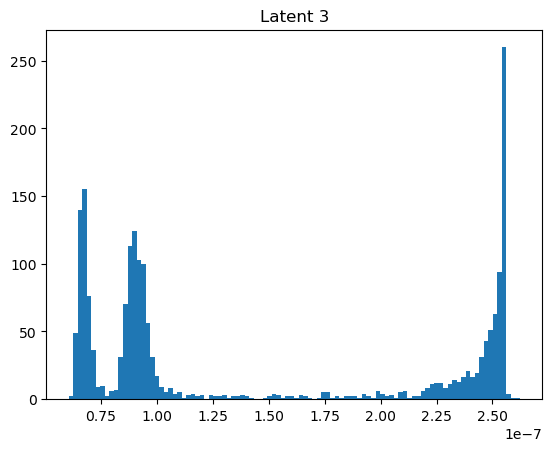

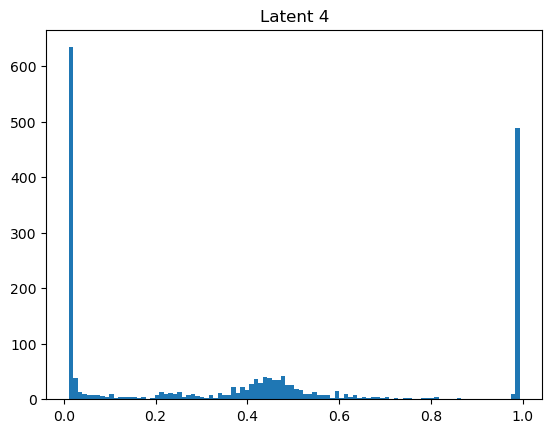

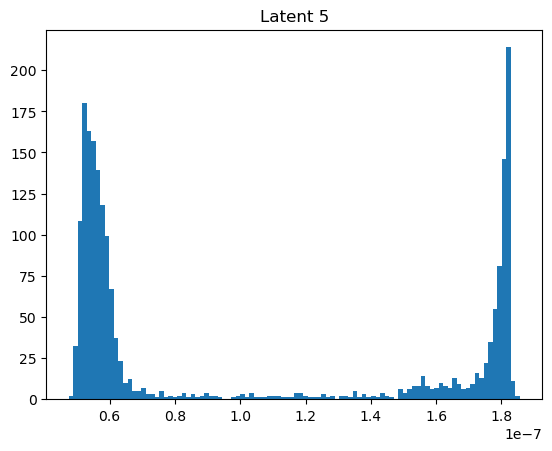

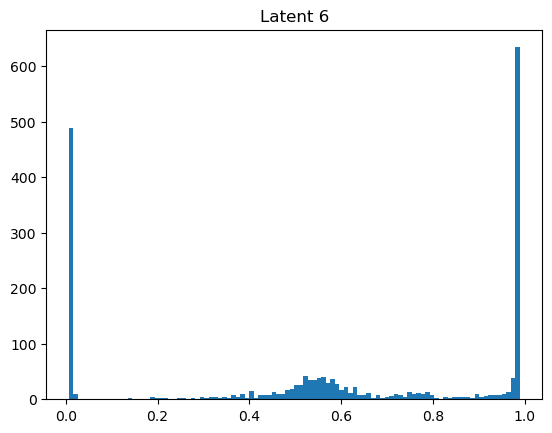

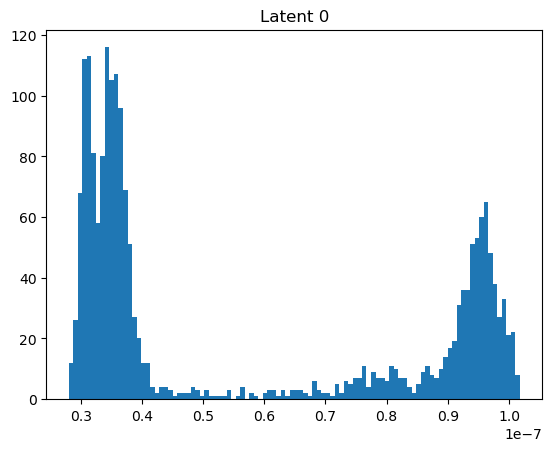

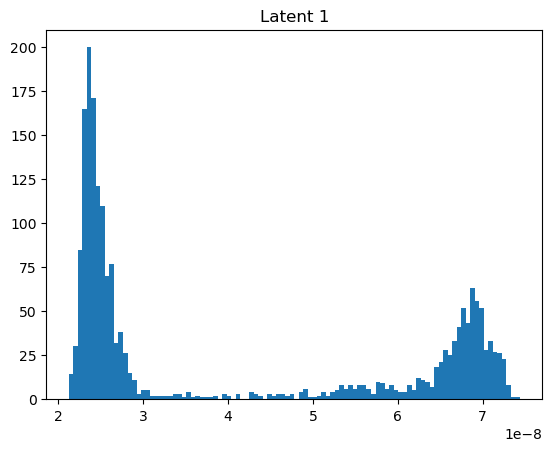

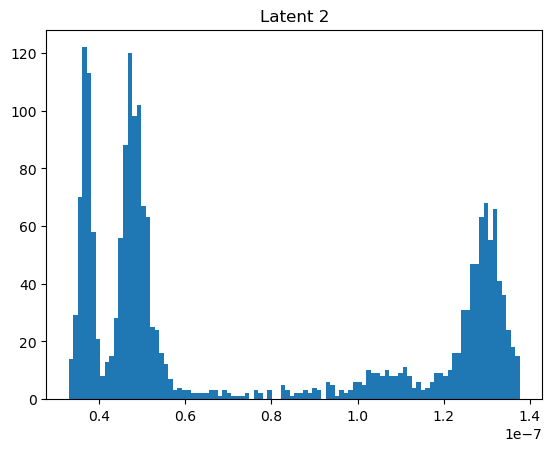

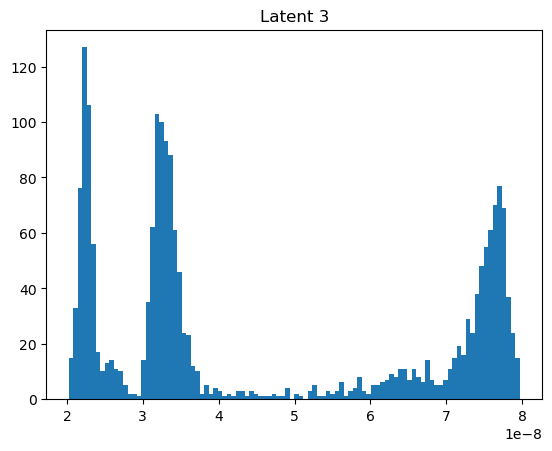

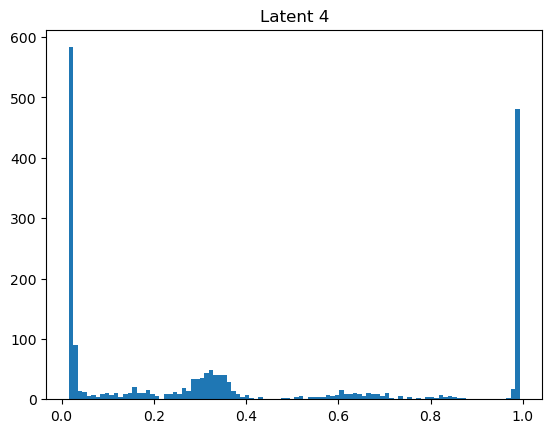

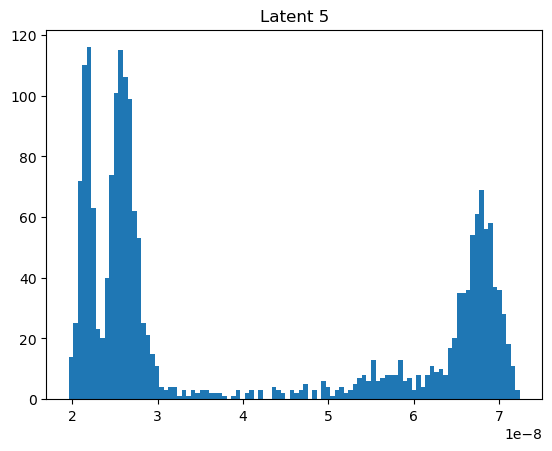

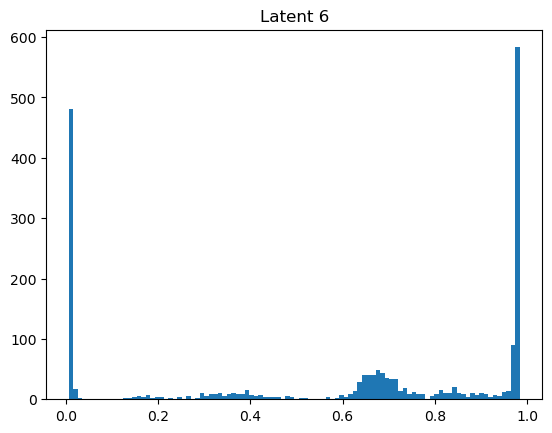

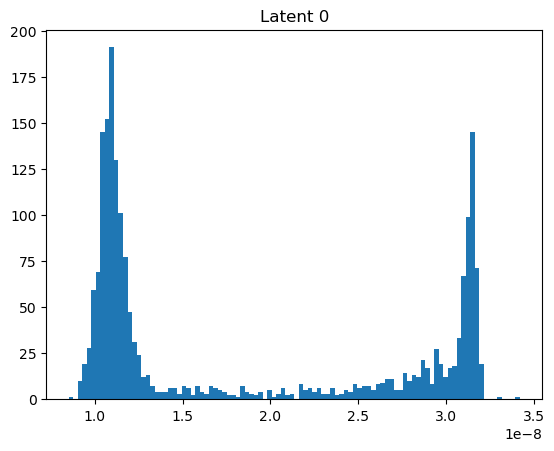

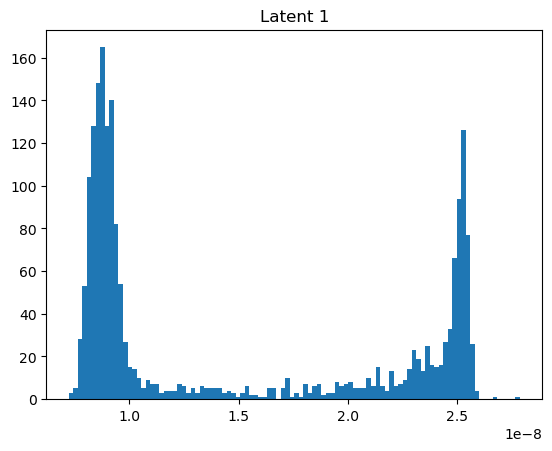

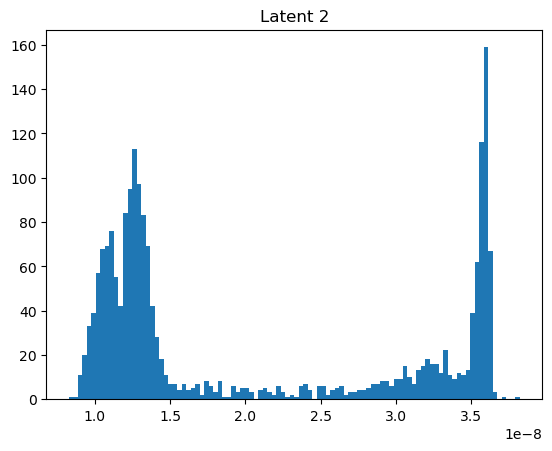

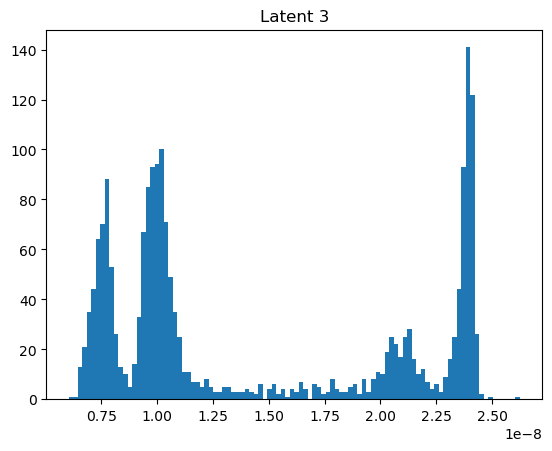

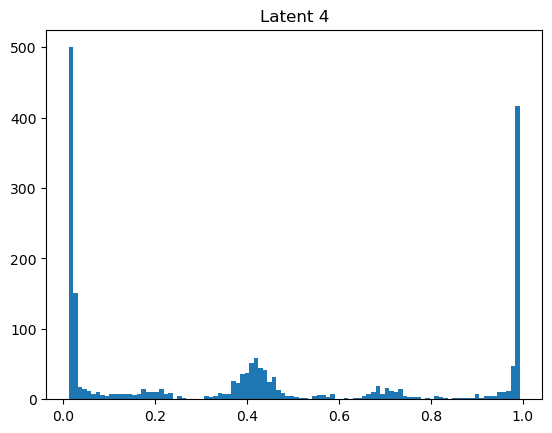

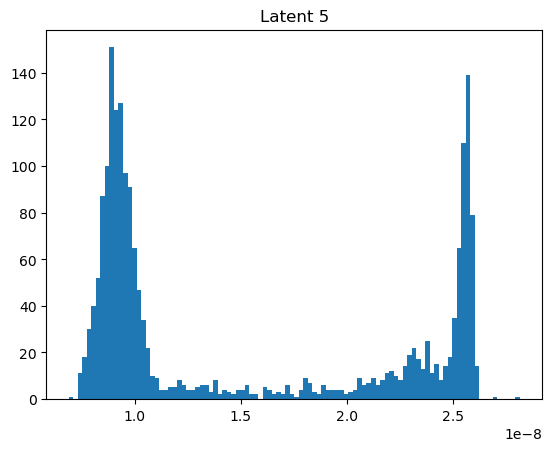

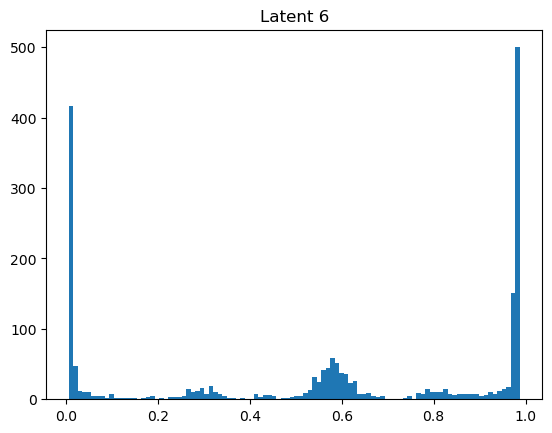

In [42]:
for latents in rmsd_latents, early_latents, final_latents:
    for i in range(latents.shape[-1]):
        plt.clf()
        plt.title(f'Latent {i}')
        _ = plt.hist(latents[:, i], bins=100)
        plt.show()

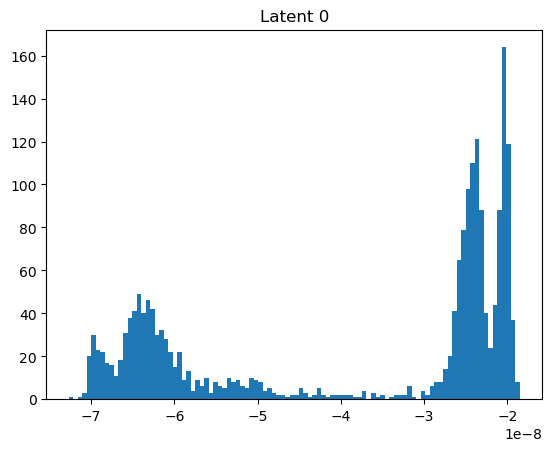

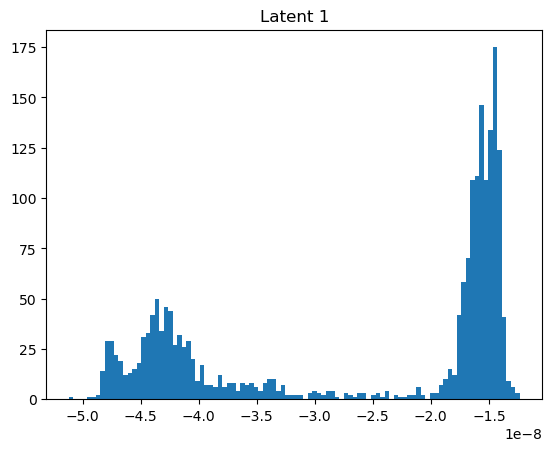

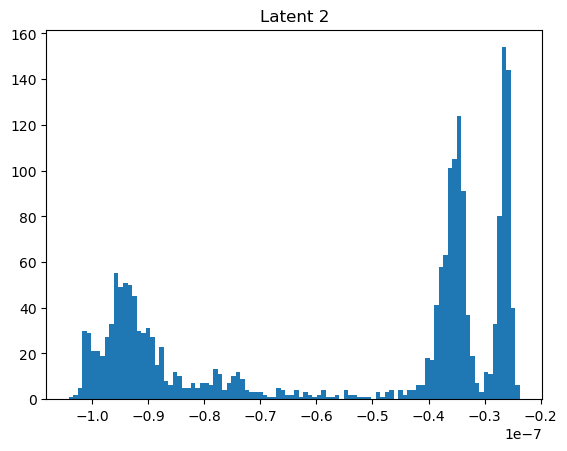

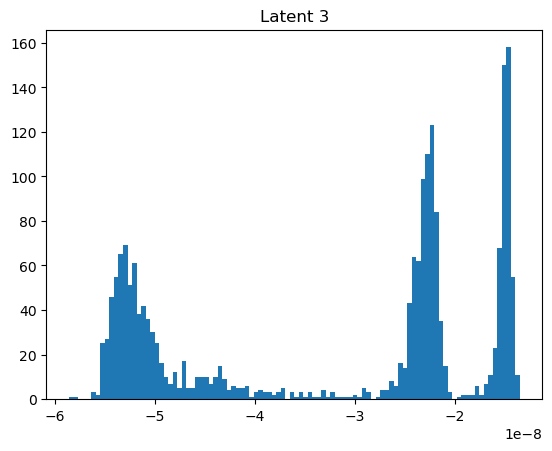

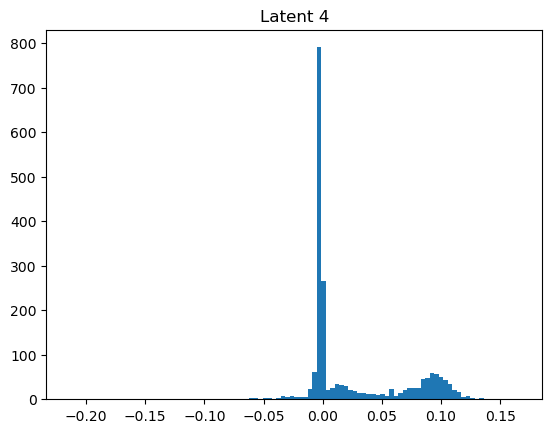

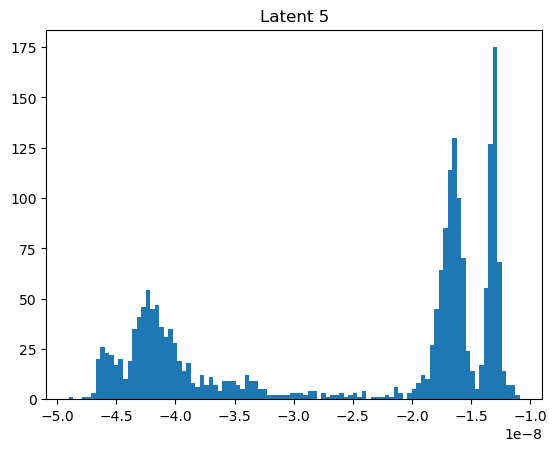

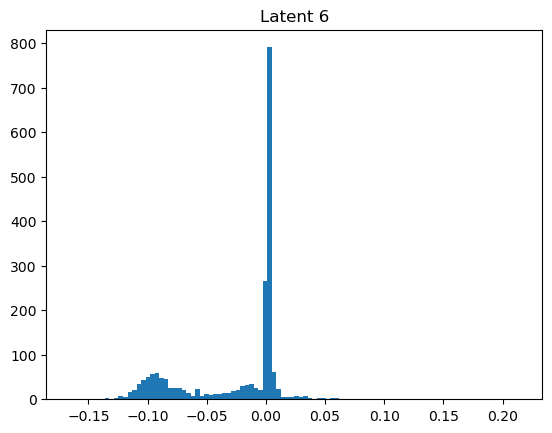

In [43]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(final_latents[:, i] - early_latents[:, i], bins=100)
    plt.show()

In [6]:
rmsds = np.load('SigSoftTest/07_latents/rpt_1/SigSoftTest07_RMSD.npy')
potentials = np.load('SigSoftTest/07_latents/rpt_1/SigSoftTest07_POTENTIAL.npy')
loss = np.load('SigSoftTest/07_latents/rpt_1/SigSoftTest07_SUMM.npy')

In [7]:
assert rmsds.shape == potentials.shape

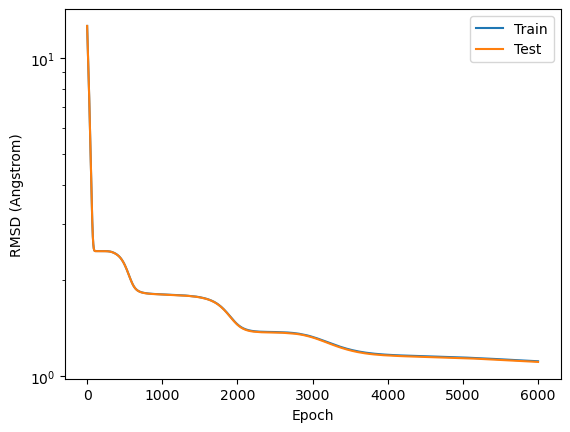

In [8]:
#RMSD
domain = np.arange(rmsds.shape[-1])

plt.clf()
plt.plot(domain, rmsds[0]*10)
plt.plot(domain, rmsds[-1]*10)
plt.xlabel('Epoch')
plt.ylabel('RMSD (Angstrom)')
plt.legend(('Train','Test'))
plt.yscale('log')
#plt.xscale('log')
plt.show()

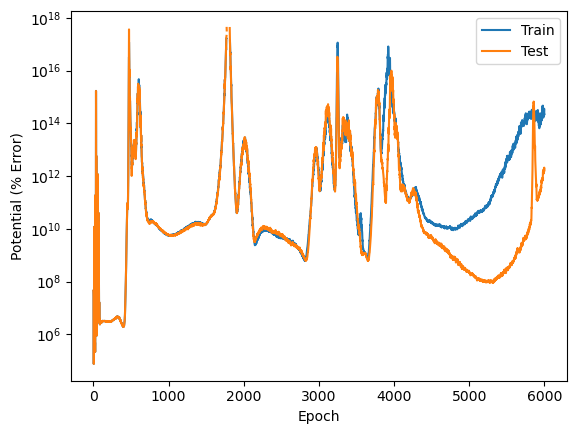

In [9]:
#POTENTIAL
plt.clf()
plt.plot(domain, np.sqrt(potentials[0]))
plt.plot(domain, np.sqrt(potentials[-1]))
plt.xlabel('Epoch')
plt.ylabel('Potential (% Error)')
plt.legend(('Train','Test'))
plt.yscale('log')
plt.xscale('linear')
plt.show()

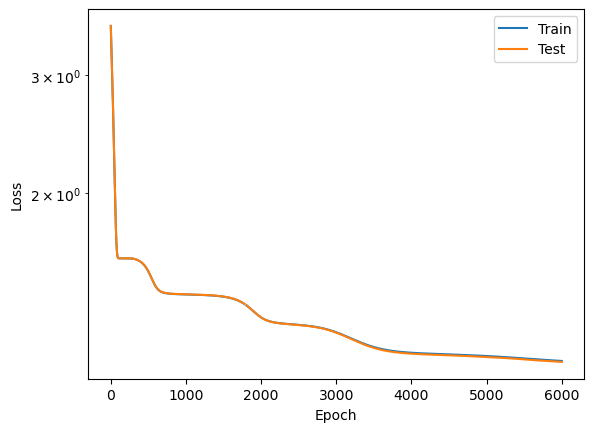

In [10]:
#POTENTIAL
plt.clf()
plt.plot(domain, np.sqrt(loss[0]))
plt.plot(domain, np.sqrt(loss[-1]))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(('Train','Test'))
plt.yscale('log')
plt.xscale('linear')
plt.show()